In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd


In [5]:
import matplotlib.pyplot as plt

In [6]:
import numpy as np


In [8]:
df = pd.read_csv(r"C:\Users\ELCOT\Downloads\aavin_sales_data.csv")

In [9]:
df.head(20) 

,order_id,order_date,district,outlet_type,product_name,category,unit_price,quantity_sold,revenue,payment_mode
0,AV006163,02-09-2025,Cuddalore,retail shop,Milk Powder 500g,MILK POWDER,216.73,20.0,4334.60,UPI
1,AV006412,19-05-2024,THANJAVUR,Aavin Parlour,Ghee 1L,Ghee,NaN,15.0,9606.30,CARD
2,AV003547,03-01-2024,Chennai,Aavin Parlour,Butter Milk 200ml,butter milk,10.58,52.0,550.16,Card
3,AV001512,17-08-2025,Vellore,Aavin Parlour,Milk Powder 500g,Milk Powder,210.56,13.0,2737.28,Cash
4,AV003222,21-04-2024,Coimbatore,retail shop,Ice Cream Cup 100ml,Ice Cream,31.04,15.0,465.60,UPI
5,AV004071,11-05-2024,erode,Aavin Parlour,Toned Milk 500ml,Milk,25.48,14.0,356.72,UPI
6,AV007800,04-09-2025,Chennai,Milk Booth,Toned Milk 500ml,Milk,25.47,20.0,509.40,Cash
7,AV005989,23-09-2025,trichy,Super Market,Sweets - Peda 250g,Sweets,118.34,13.0,1538.42,UPI
8,AV004323,21-07-2024,Salem,Aavin Parlour,Curd 400g,curd,32.91,13.0,427.83,Cash
9,AV007402,06-05-2024,Thanjavur,aavin parlour,Curd 400g,curd,34.03,14.0,476.42,Card


In [10]:
df.shape 

(8080, 10)

In [11]:
df.describe() 

,unit_price,quantity_sold,revenue
count,7840.000000,7840.000000,8080.000000
mean,160.151130,18.170153,1558.755470
std,748.792488,14.938933,2124.236209
min,9.500000,-55.000000,28.500000
25%,28.130000,8.000000,392.295000
50%,47.870000,15.000000,806.875000
75%,128.240000,24.000000,1641.695000
max,30698.500000,60.000000,13329.400000


In [12]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 8080 entries, 0 to 8079
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       8080 non-null   str    
 1   order_date     8080 non-null   str    
 2   district       7838 non-null   str    
 3   outlet_type    8080 non-null   str    
 4   product_name   8080 non-null   str    
 5   category       8080 non-null   str    
 6   unit_price     7840 non-null   float64
 7   quantity_sold  7840 non-null   float64
 8   revenue        8080 non-null   float64
 9   payment_mode   7839 non-null   str    
dtypes: float64(3), str(7)
memory usage: 631.4 KB


In [13]:
df.columns

Index(['order_id', 'order_date', 'district', 'outlet_type', 'product_name',
       'category', 'unit_price', 'quantity_sold', 'revenue', 'payment_mode'],
      dtype='str')

In [14]:
df.duplicated().sum() 


np.int64(79)

In [15]:
df = df.drop_duplicates() 

In [16]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce') 

In [17]:
df = df.dropna(subset=['order_date']) 

In [18]:
df.isnull().sum() 

order_id           0
order_date         0
district          88
outlet_type        0
product_name       0
category           0
unit_price       101
quantity_sold    101
revenue            0
payment_mode      95
dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x1a1cbf1cd70>,
 'caps': [<matplotlib.lines.Line2D at 0x1a1cbf1d010>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a1cbf1cc20>],
 'medians': [<matplotlib.lines.Line2D at 0x1a1cbf1d2b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a1cbf1d400>],
 'means': []}

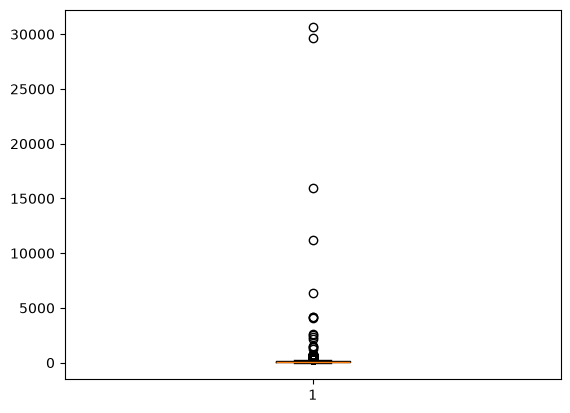

In [19]:
plt.boxplot(df['unit_price'].dropna()) 

{'whiskers': [<matplotlib.lines.Line2D at 0x1a1cbfb0d70>,
 'caps': [<matplotlib.lines.Line2D at 0x1a1cbfb1010>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a1cbfb0c20>],
 'medians': [<matplotlib.lines.Line2D at 0x1a1cbfb12b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a1cbfb1400>],
 'means': []}

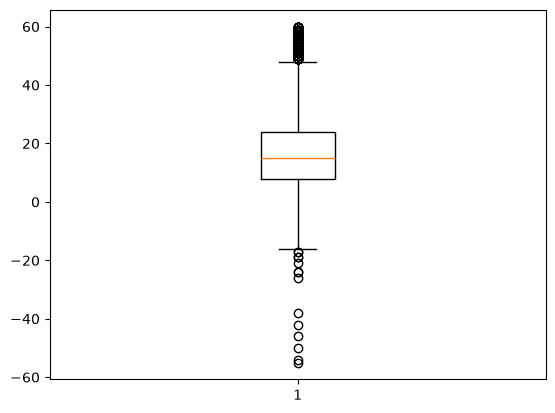

In [20]:
plt.boxplot(df['quantity_sold'].dropna()) 

In [21]:
df['quantity_sold'] = df['quantity_sold'].abs()

In [22]:
df['unit_price'] = df['unit_price'].fillna(df['unit_price'].median()) 

In [23]:
df['quantity_sold'] = df['quantity_sold'].fillna(df['quantity_sold'].median())

In [24]:
df = df.dropna(subset=['district', 'payment_mode']) 

In [25]:
text_cols = {'district', 'outlet_type', 'product_name', 'category', 'payment_mode'}

In [26]:
for col in text_cols: 
    df[col] = df[col].astype(str).str.strip().str.title() 

In [28]:
for col in text_cols: 
    print(col) 
    print(df[col].unique())
    print()

outlet_type
<StringArray>
['Retail Shop', 'Aavin Parlour', 'Milk Booth', 'Super Market',
 'Online Delivery']
Length: 5, dtype: str

product_name
<StringArray>
[     'Milk Powder 500G',     'Butter Milk 200Ml',      'Toned Milk 500Ml',
             'Curd 400G',            'Ghee 500Ml',               'Ghee 1L',
         'Toned Milk 1L',             'Curd 200G',   'Ice Cream Cup 100Ml',
    'Sweets - Peda 250G',           'Paneer 200G',           'Butter 100G',
 'Full Cream Milk 500Ml']
Length: 13, dtype: str

district
<StringArray>
[  'Cuddalore',     'Chennai',       'Erode',   'Thanjavur',     'Vellore',
    'Dindigul',  'Coimbatore',      'Trichy', 'Kanchipuram',     'Madurai',
       'Salem', 'Tirunelveli']
Length: 12, dtype: str

category
<StringArray>
['Milk Powder', 'Butter Milk',        'Milk',        'Curd',        'Ghee',
   'Ice Cream',      'Sweets',      'Paneer',      'Butter']
Length: 9, dtype: str

payment_mode
<StringArray>
['Upi', 'Card', 'Cash', 'Wallet']
Length: 4, dt

In [29]:
df.shape 

(2994, 10)

In [30]:
df.duplicated().sum() 

np.int64(0)

In [31]:
df.isnull().sum() 

order_id         0
order_date       0
district         0
outlet_type      0
product_name     0
category         0
unit_price       0
quantity_sold    0
revenue          0
payment_mode     0
dtype: int64

In [32]:
df.info()

<class 'pandas.DataFrame'>
Index: 2994 entries, 0 to 8079
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       2994 non-null   str           
 1   order_date     2994 non-null   datetime64[us]
 2   district       2994 non-null   str           
 3   outlet_type    2994 non-null   str           
 4   product_name   2994 non-null   str           
 5   category       2994 non-null   str           
 6   unit_price     2994 non-null   float64       
 7   quantity_sold  2994 non-null   float64       
 8   revenue        2994 non-null   float64       
 9   payment_mode   2994 non-null   str           
dtypes: datetime64[us](1), float64(3), str(6)
memory usage: 257.3 KB


In [33]:
df['month'] = df['order_date'].dt.to_period('M') 

In [34]:
df['year'] = df['order_date'].dt.year 

In [ ]:
 How is Aavin's revenue changing month by month?

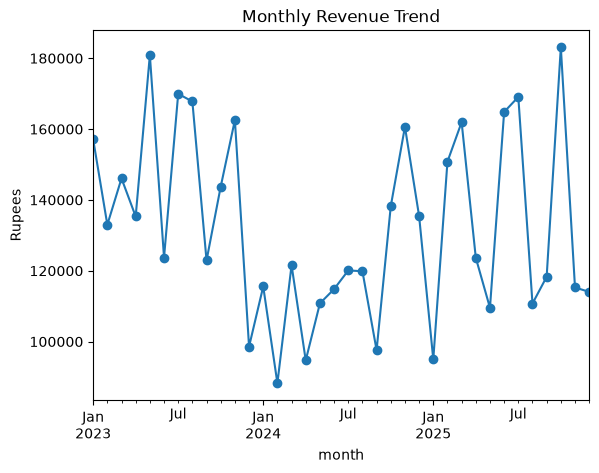

In [35]:
df.groupby('month')['revenue'].sum().plot(kind='line', marker='o') 
plt.title("Monthly Revenue Trend") 
plt.ylabel("Rupees") 
plt.show() 

In [ ]:
Which outlet type has the highest average order value? 

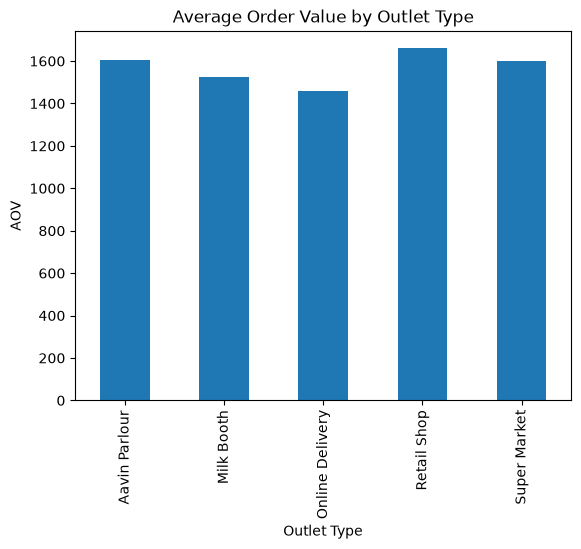

In [36]:
df.groupby('outlet_type')['revenue'].mean().plot(kind='bar') 
plt.title("Average Order Value by Outlet Type") 
plt.ylabel("AOV") 
plt.xlabel("Outlet Type") 
plt.show() 


In [ ]:
Which product category contributes the most to total revenue? 

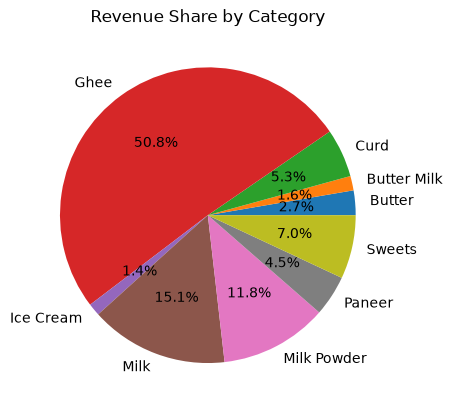

In [37]:
df.groupby('category')['revenue'].sum().plot(kind='pie', autopct='%1.1f%%') 
plt.title("Revenue Share by Category") 
plt.show() 

In [ ]:
Which districts generate the highest revenue?

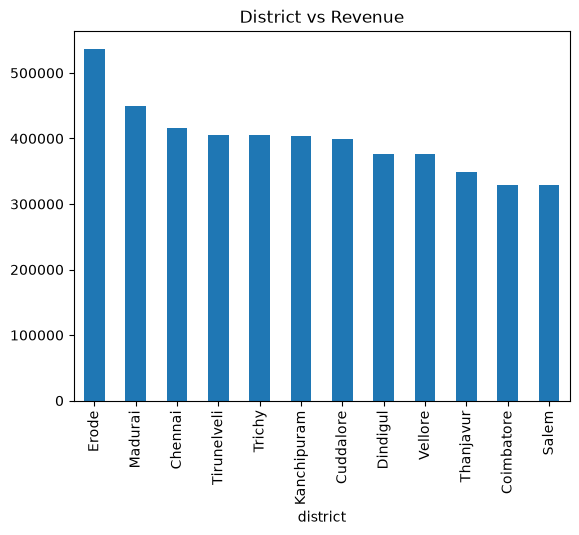

In [38]:
district_rev = df.groupby('district')['revenue'].sum().sort_values(ascending=False) 
district_rev.plot(kind='bar') 
plt.title("District vs Revenue") 
plt.show() 

In [ ]:
Which payment mode is most commonly used by customers? 

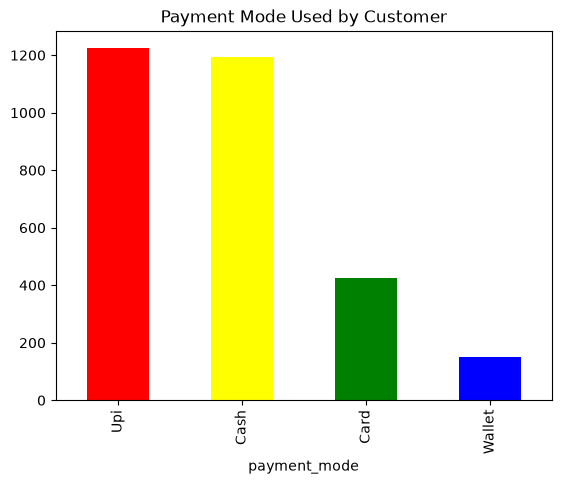

In [39]:
payment = df['payment_mode'].value_counts() 
payment.plot(kind='bar', color=['red', 'yellow', 'green', 'blue']) 
plt.title("Payment Mode Used by Customer") 
plt.show() 

In [ ]:
## Key Takeaways

- Monthly revenue showed a fluctuating trend with several peaks and dips across the analyzed period.
- Retail Shop recorded the highest average order value at approximately ₹1,650 per order.
- Ghee contributed the largest share of total revenue, accounting for approximately 50.8%.
- Erode, Madurai and Chennai were the top three districts by revenue, while Salem, Coimbatore and Thanjavur were the bottom three.
- UPI was the most commonly used payment mode, followed closely by Cash.